In [1]:
import os
import json
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
import numpy as np

In [2]:
def get_dataset_name(dataset_id, nnUNet_raw="data/nnUNet_raw"):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [dataset_name for dataset_name in os.listdir(nnUNet_raw) if dataset_name.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, dataset_name))]
    assert len(dataset_name) == 1, f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1"
    return dataset_name[0]

def extract_params(model_dir):
    metrics_file = f"{model_dir}/model_analysis.json"
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['parameters']['total']

def get_results(model_dir, split="val", fold=0):
    if split == "val":
        metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
    else:
        raise ValueError(f"Not implemented for split {split}")
    
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['foreground_mean']

In [3]:
def get_baseline_results_from_log(model_dir):
    log_path = f"{model_dir}/fold_0/log.csv"
    df = pd.read_csv(log_path)
    dice = df['val_dice'].iloc[-1]
    return dice

def get_baseline_results_csv(model_dir, dataset_name):
    log_path = f"{model_dir}/fold_0/test/results.csv"
    df = pd.read_csv(log_path)
    dice = df[df['test_dataset_name'] == dataset_name]['dice'].values[0]
    return dice / 100


def get_baseline_results(dataset_id, models=["TinyUNet", "CMUNeXt", "UNeXt"], results_dir="data/nnUNet_results"):
    cfg = "2d"
    dataset_name = get_dataset_name(dataset_id)
        
    results = {model: {'dice': None, 'params': None} for model in models}
    for model in models:
        if model == "TinyUNet":
            trainer = "TinyUNetTrainer"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/{model}/{dataset_name}"
        elif model == "CMUNeXt":
            trainer = "CMUNeXtTrainer"
            model_dir = f"/home/ultrai/UltrAi/CMUNeXt/models/CMUNeXt-S/{dataset_name}"
        elif model == "UNeXt":
            # dataset_id = 303
            # dataset_name = get_dataset_name(dataset_id)
            trainer = "UNeXtTrainer_100epochs"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/UNext/{dataset_name}"
        else:
            raise ValueError(f"Unknown model: {model}. Please choose from {', '.join(models)}")

        params = extract_params(model_dir)
        # dice = get_results(model_dir, split=split, fold=fold)['Dice']
        if model == "CMUNeXt":
            dice = get_baseline_results_csv(model_dir, dataset_name)
        else:
            dice = get_baseline_results_from_log(model_dir)
        results[model]['dice'] = round(dice * 100, 2)
        results[model]['params'] = params
    return results


def get_metric(cfg, dataset_name, metric="naswot", naswot_dir="results/nas_metrics", encoder_only=False, use_pretrained=False, batches=100):
    if encoder_only:
        naswot_csv = join(naswot_dir, f"{dataset_name}_metrics_encoder_only_b{batches}.csv")
    else:
        naswot_csv = join(naswot_dir, f"{dataset_name}_metrics_b{batches}.csv")
    if use_pretrained:
        naswot_csv = naswot_csv.replace("metrics_", "metrics_pretrained_")
    if not os.path.exists(naswot_csv):
        return None
    df = pd.read_csv(naswot_csv)
    if df.empty or "cfg" not in df.columns:
        return None

    # Replace infinite values with NaN, then interpolate numeric columns only (avoids object-dtype warning)
    df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].interpolate(axis=0, method='linear', limit_direction='both')

    df = df[df['cfg'] == cfg]
    if df.empty:
        return None
    nas_metric = df[metric].iloc[-1]
    # if metric == "jacobian":
    #     nas_metric = - nas_metric
    return nas_metric


In [4]:
trainer = "nnUNetTrainer_100epochs"
plans = "nnUNetPlans"
results_dir = "data/nnUNet_results"
model = "nnunet"
fold = 0
split = "val"

In [5]:
def select_precollapse_config_from_metric(params_list, metric_list, pre_collapse_rank=1, min_seg=2):
    """Select pre-collapse config using only curve shape.

    Fits a 2-segment piecewise linear model on (log10(params), metric).
    The breakpoint estimates the collapse boundary (small-model side vs stable side).

    Returns:
      pick_idx, boundary_idx, fit_info
    """
    x = np.asarray(params_list, dtype=float)
    y = np.asarray([np.nan if pd.isna(v) else float(v) for v in metric_list], dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)

    if valid.sum() < (2 * min_seg + 1):
        return None, None, None

    valid_idx = np.flatnonzero(valid)
    xv = np.log10(x[valid])
    yv = np.clip(y[valid], 1e-12, None)

    n = len(xv)
    if n < (2 * min_seg + 1):
        return None, None, None

    best_b = None
    best_sse = np.inf
    best_fit = None

    for b in range(min_seg - 1, n - min_seg):
        x1, y1 = xv[: b + 1], yv[: b + 1]
        x2, y2 = xv[b + 1 :], yv[b + 1 :]

        p1 = np.polyfit(x1, y1, 1)
        p2 = np.polyfit(x2, y2, 1)

        y1_hat = p1[0] * x1 + p1[1]
        y2_hat = p2[0] * x2 + p2[1]
        sse = np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2)

        if sse < best_sse:
            best_sse = sse
            best_b = b
            best_fit = {
                'left_idx': valid_idx[: b + 1].copy(),
                'right_idx': valid_idx[b + 1 :].copy(),
                'y1_hat': y1_hat.copy(),
                'y2_hat': y2_hat.copy(),
                'boundary_left_idx': int(valid_idx[b]),
                'boundary_right_idx': int(valid_idx[b + 1]),
            }

    if best_b is None:
        return None, None, None

    # Boundary is between valid positions best_b and best_b+1.
    # Pre-collapse picks are on the stable (larger-model) side: best_b+1, best_b+2, ...
    pick_valid_pos = best_b + int(pre_collapse_rank)
    if pick_valid_pos >= len(valid_idx):
        pick_valid_pos = len(valid_idx) - 1

    pick_idx = int(valid_idx[pick_valid_pos])
    boundary_idx = int(valid_idx[best_b + 1])
    return pick_idx, boundary_idx, best_fit


saved to results/naswot_b32_dice_vs_params_with_metric_fit.png


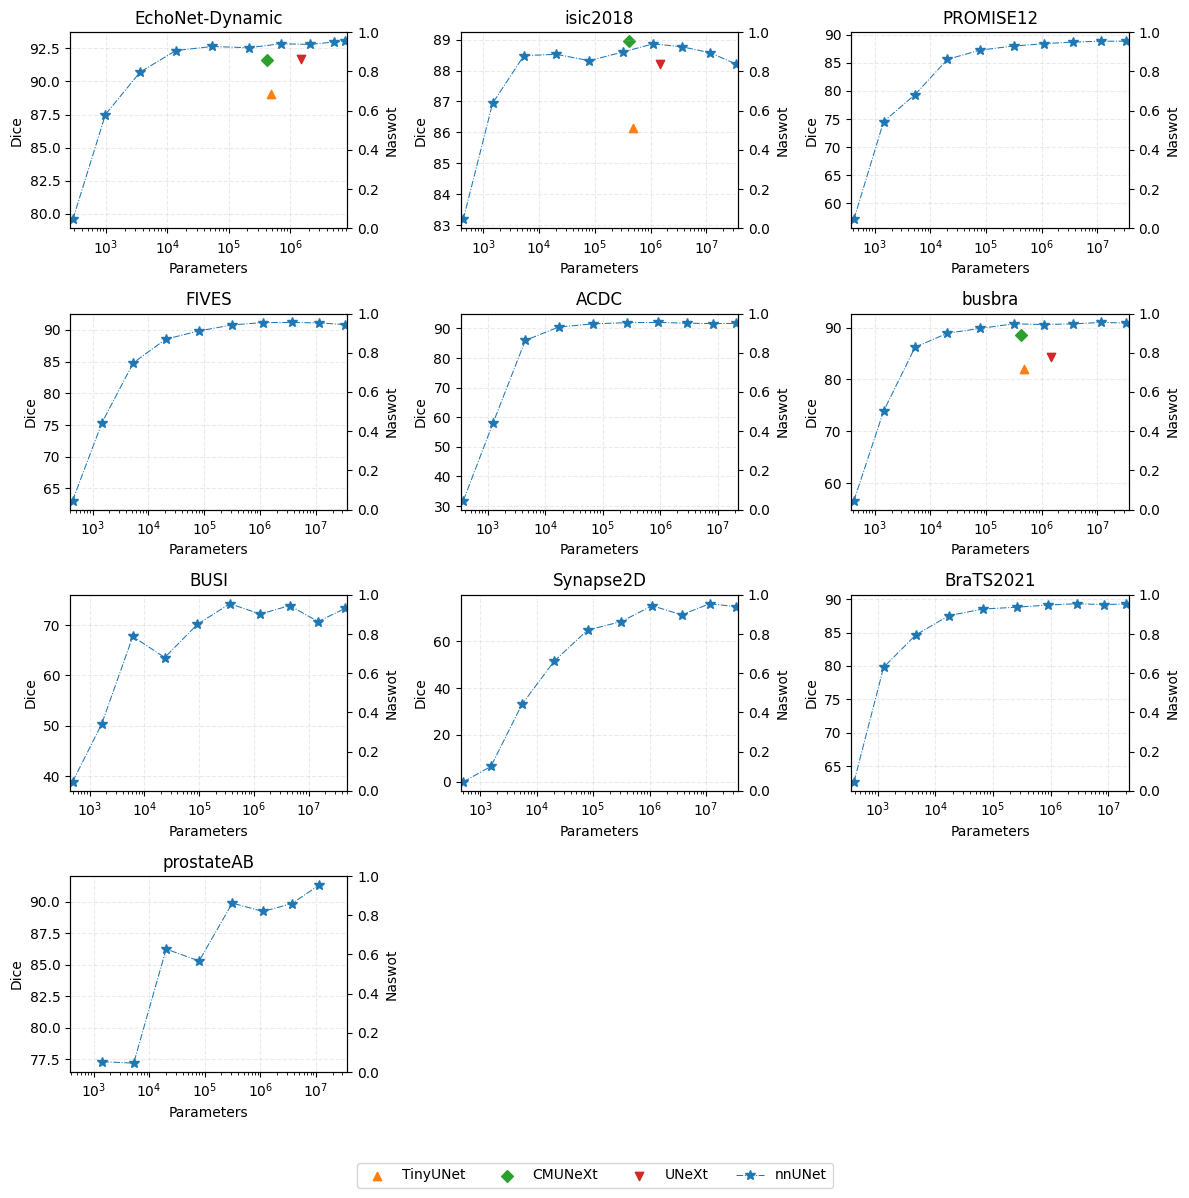

In [10]:
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

baselines = [
    "TinyUNet",
    "CMUNeXt",
    "UNeXt"
]

dataset_ids = [
    302,
    300,
    308,
    309,
    306,
    301,
    304,
    305,
    137,
    307,
    # 312,
    # 310,
]

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

# NASWOT settings
batches = "32"
encoder_only = False
use_pretrained = False
use_relative_change = False
use_derivative = False
metric_precollapse_rank = 1
min_seg = 2
plot_metric_fit_lines = True
# metric = "jacobian"
metric = "naswot"
# metric = "swap"
# metric = "ncd_swap"
# metric = "ncd_naswot"
# metric = "synflow"
# metric = "gradnorm"
# metric = "snip"
# metric = "fisher"

# fig = plt.figure(figsize=(8.5, 2.65))
fig = plt.figure(figsize=(12, 12))
# fig = plt.figure(figsize=(20, 3))
for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)
    params_list = []
    dice_list = []
    nas_metric_list = []

    for cfg in cfgs:
        # if dataset_id == 301 and cfg == "2d_tiny1":
        #     continue
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        params = extract_params(model_dir)
        dice = np.nan
        try:
            dice = get_results(model_dir, split=split, fold=fold)['Dice'] * 100
        except FileNotFoundError:
            pass
        nas_metric = get_metric(cfg, dataset_name, metric=metric, encoder_only=encoder_only, use_pretrained=use_pretrained, batches=batches)
        # print(f"{cfg}: {params}: {dice:.2f}% {nas_metric}")
        params_list.append(params)
        dice_list.append(dice)
        nas_metric_list.append(nas_metric)
    
    
    plt.subplot((len(dataset_ids) + 2)//3, 3, i + 1)
    ax = plt.gca()

    # colors = sns.color_palette("Blues", n_colors=len(baselines), desat=0.7) #[:-1] + [sns.color_palette("Reds", n_colors=2)[-1]]
    colors = sns.color_palette(n_colors=len(baselines) + 1)
    markers = ['^', 'D', 'v', 'X', '^', '<', '>', 'p', 'h', 'H', '8', '1']
    if dataset_id in [300, 301, 302]:
        baseline_results = get_baseline_results(dataset_id, models=baselines, results_dir=results_dir)
        
        for b, baseline_model in enumerate(baselines):
            dice = baseline_results[baseline_model]['dice']
            params = baseline_results[baseline_model]['params']
            label = baseline_model if i == 0 else "_nolegend_"
            ax.scatter(params, dice, label=label, color=colors[b+1], marker=markers[b])
    
    params_arr = np.asarray(params_list, dtype=float)
    valid_params = np.isfinite(params_arr) & (params_arr > 0)
    dice_arr = np.asarray(dice_list, dtype=float)
    label = "nnUNet" if i == 0 else "_nolegend_"
    valid_dice = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(dice_arr)
    if np.any(valid_dice):
        ax.plot(params_arr[valid_dice], dice_arr[valid_dice], marker='*', linestyle='dashdot', linewidth=0.75, markersize=7, color=colors[0], label=label)
    ax2 = ax.twinx()
    nas_metrics = np.asarray([np.nan if pd.isna(n) else float(n) for n in nas_metric_list], dtype=float)
    valid_nas = np.isfinite(nas_metrics)
    if np.any(valid_nas):
        nas_min = np.nanmin(nas_metrics)
        nas_max = np.nanmax(nas_metrics)
        if nas_max > nas_min:
            nas_metrics = (nas_metrics - nas_min) / (nas_max - nas_min)
    selected_cfg_idx = None
    
    # if metric == "jacobian":
    #     # ax2.invert_yaxis()
    #     # ax2.set_yscale('log')
    
    naswot_label = f'{metric}' if i == 0 else '_nolegend_'

    assert not (use_relative_change and use_derivative), "Cannot use both relative change and derivative"
    if use_relative_change:
        nas_metrics = [np.nan] + [abs(nas_metrics[j] - nas_metrics[j - 1]) for j in range(1, len(nas_metrics))]
        valid = [x for x in nas_metrics if not np.isnan(x)]
        if len(valid) > 0 and (max(valid) - min(valid)) > 0:
            nas_metrics = [np.nan if np.isnan(x) else (x - min(valid)) / (max(valid) - min(valid)) for x in nas_metrics]
    elif use_derivative:
        nas_metrics = [np.nan] + [
            abs(nas_metrics[j] - nas_metrics[j-1]) / abs(np.log10(params_list[j]) - np.log10(params_list[j-1]))
            if params_list[j] > 0 and params_list[j-1] > 0 and (np.log10(params_list[j]) - np.log10(params_list[j-1])) != 0
            else np.nan
            for j in range(1, len(nas_metrics))
        ]

    nas_metrics = np.asarray(nas_metrics, dtype=float)
    valid_nas_plot = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(nas_metrics)
    if np.any(valid_nas_plot):
        metric_linestyle = 'None' if plot_metric_fit_lines else '-'
        metric_linewidth = 0.0 if plot_metric_fit_lines else 0.75
        ax2.plot(
            params_arr[valid_nas_plot],
            nas_metrics[valid_nas_plot],
            marker='o',
            linestyle=metric_linestyle,
            linewidth=metric_linewidth,
            markersize=4,
            color='black',
            alpha=0.6,
            label=naswot_label,
        )
        
    metric_fit_info = None
    selected_cfg_idx, transition_idx, metric_fit_info = select_precollapse_config_from_metric(
        params_list, nas_metrics, pre_collapse_rank=metric_precollapse_rank, min_seg=min_seg
    )

    if metric_fit_info is not None and plot_metric_fit_lines:
        left_idx = metric_fit_info['left_idx']
        right_idx = metric_fit_info['right_idx']
        y1_hat = metric_fit_info['y1_hat']
        y2_hat = metric_fit_info['y2_hat']

        x_left = params_arr[left_idx]
        x_right = params_arr[right_idx]

        fit1_label = 'metric fit 1' if i == 0 else '_nolegend_'
        fit2_label = 'metric fit 2' if i == 0 else '_nolegend_'
        ax2.plot(x_left, y1_hat, linestyle='-', linewidth=1.1, color='tab:orange', alpha=0.95, label=fit1_label)
        ax2.plot(x_right, y2_hat, linestyle='-', linewidth=1.1, color='tab:green', alpha=0.95, label=fit2_label)

        split_label = 'split b|b+1' if i == 0 else '_nolegend_'
        bl = metric_fit_info['boundary_left_idx']
        br = metric_fit_info['boundary_right_idx']
        if np.isfinite(params_arr[bl]) and np.isfinite(params_arr[br]) and params_arr[bl] > 0 and params_arr[br] > 0:
            split_x = 10 ** ((np.log10(params_arr[bl]) + np.log10(params_arr[br])) / 2.0)
            ax2.axvline(split_x, linestyle=':', linewidth=1.0, color='red', alpha=0.8, label=split_label)

    
    ax2.set_ylabel(f'{metric.capitalize()}')
    # if metric == "jacobian":
    #     ax2.invert_yaxis()
    drop_label = "1% drop" if i == 0 else "_nolegend_"
    # ax.hlines(dice_list[-1]-1, params_list[0], params_list[-1], colors='red', linestyles='dashed', linewidth=0.75, label=drop_label)
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Dice')
    ax.set_title(f'{dataset_name.split("_")[1]}')
    if np.any(valid_params):
        x_pos = params_arr[valid_params]
        ax.set_xlim(x_pos.min() * 0.9, x_pos.max() * 1.1)
        ax.set_xscale('log')
    # if dataset_id == 301:
    #     ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    # elif dataset_id == 302:
    #     ax.yaxis.set_major_locator(plt.MultipleLocator(4))
    # else:
    #     ax.yaxis.set_major_locator(plt.MultipleLocator(2))

    if selected_cfg_idx is not None and np.isfinite(params_arr[selected_cfg_idx]) and params_arr[selected_cfg_idx] > 0:
        pick_label = "Metric pick" if i == 0 else "_nolegend_"

        # Always highlight the selected cfg on the selected metric curve
        if np.isfinite(nas_metrics[selected_cfg_idx]):
            ax2.scatter(
                params_arr[selected_cfg_idx],
                nas_metrics[selected_cfg_idx],
                marker='o',
                s=60,
                facecolors='none',
                edgecolors='magenta',
                linewidths=1.5,
                zorder=7,
                label=pick_label,
            )

    ax.grid(True, alpha=0.25, linestyle='--')

# ONE figure-level legend (labels only come from the first subplot)
fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=7)

save_path = f'{save_dir}/{metric}_b{batches}_dice_vs_params.png'
if use_pretrained:
    save_path = save_path.replace("dice_vs_params", "dice_vs_params_pretrained")
if use_relative_change:
    save_path = save_path.replace("dice_vs_params", "dice_vs_params_relative_change")
elif use_derivative:
    save_path = save_path.replace("dice_vs_params", "dice_vs_params_derivative")
if plot_metric_fit_lines:
    save_path = save_path.replace(".png", "_with_metric_fit.png")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"saved to {save_path}")
plt.show()

302 Dataset302_EchoNet-Dynamic
300 Dataset300_isic2018
308 Dataset308_PROMISE12


/tmp/ipykernel_1629639/2886545268.py:18: RuntimeWarning: All-NaN slice encountered
  nas_metric_list = (nas_metric_list - np.nanmin(nas_metric_list)) / (np.nanmax(nas_metric_list) - np.nanmin(nas_metric_list))
/tmp/ipykernel_1629639/2886545268.py:18: RuntimeWarning: All-NaN slice encountered
  nas_metric_list = (nas_metric_list - np.nanmin(nas_metric_list)) / (np.nanmax(nas_metric_list) - np.nanmin(nas_metric_list))


TypeError: '<=' not supported between instances of 'NoneType' and 'NoneType'

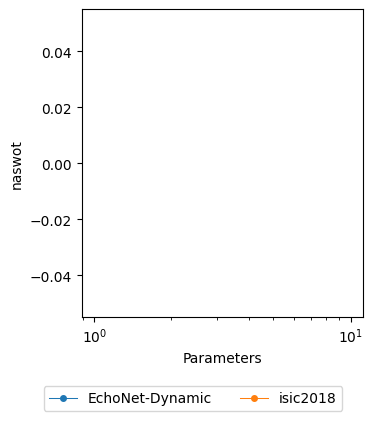

In [7]:
plt.figure(figsize=(8, 4))
for dataset_id in dataset_ids:
    dataset_name = get_dataset_name(dataset_id)
    print(dataset_id, dataset_name)
    params_list = []
    nas_metric_list = []
    dice_list = []
    for cfg in cfgs:
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        params = extract_params(model_dir)
        # dice = get_results(model_dir, split=split, fold=fold)['Dice'] * 100
        nas_metric = get_metric(cfg, dataset_name, metric=metric, use_pretrained=use_pretrained, encoder_only=encoder_only, batches=batches)
        params_list.append(params)
        # dice_list.append(dice)
        nas_metric_list.append(nas_metric)
    
    nas_metric_list = np.array(nas_metric_list)
    nas_metric_list = (nas_metric_list - np.nanmin(nas_metric_list)) / (np.nanmax(nas_metric_list) - np.nanmin(nas_metric_list))
    # dice_list = np.array(dice_list)
    # dice_list = (dice_list - np.nanmin(dice_list)) / (np.nanmax(dice_list) - np.nanmin(dice_list))

    # plt.subplot(1, 2, 1)
    # plt.plot(params_list, dice_list, marker='o', linestyle='-', linewidth=0.75, markersize=4, label=dataset_name.split("_")[1])
    # plt.xscale('log')
    # plt.ylabel('Dice')
    # plt.xlabel('Parameters')
    # plt.grid(True, alpha=0.25, linestyle='--')
    # plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(params_list, nas_metric_list, marker='o', linestyle='-', linewidth=0.75, markersize=4, label=dataset_name.split("_")[1])
    plt.xscale('log')
    plt.xlabel('Parameters')
    plt.ylabel(metric)
    plt.legend(ncol=2, bbox_to_anchor=(0.95, -0.2))
plt.grid(True, alpha=0.25, linestyle='--')
# plt.ylim(0.94, 1.05)
# plt.xlim(1e4, 1e8)
plt.tight_layout()
save_path = f"{save_dir}/norm_dice_metric_vs_params.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"saved to {save_path}")
plt.show()

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

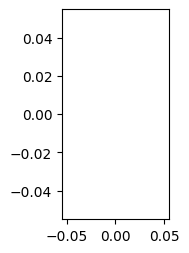

In [ ]:
# Correlation analysis (Dice vs metric)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corr_rows = []
fig = plt.figure(figsize=(8, 6))

for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)
    dice_list = []
    metric_list = []

    for cfg in cfgs:
        # skip second config for busbra (outlier)
        # if dataset_id == 301 and cfg == "2d_tiny1":
        #     continue
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        dice = get_results(model_dir, split=split, fold=fold)['Dice'] * 100
        m = get_metric(cfg, dataset_name, metric=metric, encoder_only=encoder_only, batches=batches)
        if m is None:
            continue
        dice_list.append(dice)
        metric_list.append(m)

    if len(dice_list) < 2:
        corr_rows.append({"dataset": dataset_name, "n": len(dice_list), "pearson": np.nan, "spearman": np.nan})
        continue

    s = pd.Series(dice_list)
    m = pd.Series(metric_list)
    pearson = s.corr(m, method='pearson')
    spearman = s.corr(m, method='spearman')
    corr_rows.append({"dataset": dataset_name, "n": len(s), "pearson": pearson, "spearman": spearman})

    plt.subplot(2, len(dataset_ids)//2, i + 1)
    ax = plt.gca()
    ax.scatter(m, s, s=20, alpha=0.8)
    if len(m) >= 2:
        coef = np.polyfit(m, s, 1)
        xfit = np.linspace(m.min(), m.max(), 100)
        yfit = coef[0] * xfit + coef[1]
        ax.plot(xfit, yfit, color="gray", linewidth=1, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_ylabel("Dice")
    ax.set_title(f"{dataset_name.split("_")[1]}\nPearson={pearson:.3f}\nSpearman={spearman:.3f}")
    ax.grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig(f"{save_dir}/{metric}_corr_vs_dice.png", dpi=300, bbox_inches='tight')
plt.show()

corr_df = pd.DataFrame(corr_rows)
print(corr_df)
